# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omi290/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!pip -q install duckdb huggingface_hub pyarrow pandas

In [3]:
from google.colab import userdata
from huggingface_hub import hf_hub_download
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = userdata.get("HF_TOKEN")

In [4]:
march_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=HF_TOKEN
)

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

In [5]:
db = duckdb.connect()

In [6]:
db.sql(f"""
CREATE OR REPLACE TABLE march_data AS
SELECT *
FROM read_parquet('{march_path}')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [7]:
feature_vector = db.sql("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_pageviews,
    ga4_sessions,
    scroll_events

FROM march_data

WHERE ga4_data_available IS TRUE
""").df()

feature_vector.head()

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events
0,2026-03-01,client_65de48885f4ef01b,content_09be8cc7fcb222af,0,0,NaN,1,1,0
1,2026-03-01,client_65de48885f4ef01b,content_851afac9fe13612e,0,0,NaN,1,1,0
2,2026-03-01,client_65de48885f4ef01b,content_cee6c6fc8c51af14,0,0,NaN,1,1,0
3,2026-03-01,client_65de48885f4ef01b,content_5e120e972f11f833,0,0,NaN,1,1,0
4,2026-03-01,client_65de48885f4ef01b,content_16a7291bb6ecaebe,0,0,NaN,1,1,0


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

# Ranked Actions

This playbook prioritizes historical content using observed search visibility and engagement signals.

Each recommendation includes:

- Priority Score
- Reason Code
- Suggested Action

In [8]:
baseline = feature_vector.copy()

baseline["priority_score"] = (
      baseline["gsc_impressions"]*0.4
    + baseline["gsc_clicks"]*0.3
    + baseline["ga4_pageviews"]*0.2
    + baseline["scroll_events"]*0.1
)

baseline["reason_code"] = np.where(
    baseline["gsc_clicks"]==0,
    "LOW_CTR",
    "HIGH_VALUE"
)

baseline["action"] = np.where(
    baseline["priority_score"]>1000,
    "Refresh Content",
    "Monitor"
)

baseline = baseline.sort_values(
    "priority_score",
    ascending=False
)

baseline.head(20)

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events,priority_score,reason_code,action
326311,2026-03-29,client_e547b89c05043229,content_eadb33b5df496f4a,39305,252,2.197507,129,122,26,15826.0,HIGH_VALUE,Refresh Content
382210,2026-03-28,client_e547b89c05043229,content_eadb33b5df496f4a,38436,271,2.195988,145,141,16,15486.3,HIGH_VALUE,Refresh Content
368810,2026-03-30,client_e547b89c05043229,content_eadb33b5df496f4a,35404,225,2.188397,113,104,13,14253.0,HIGH_VALUE,Refresh Content
354976,2026-03-27,client_e547b89c05043229,content_eadb33b5df496f4a,34817,223,2.181348,121,116,13,14019.2,HIGH_VALUE,Refresh Content
409923,2026-03-31,client_e547b89c05043229,content_eadb33b5df496f4a,34606,235,2.242501,123,118,23,13939.8,HIGH_VALUE,Refresh Content
283865,2026-03-24,client_e547b89c05043229,content_eadb33b5df496f4a,33571,215,2.309046,122,116,14,13518.7,HIGH_VALUE,Refresh Content
349759,2026-03-27,client_23a62021009f63c4,content_44f34c0a90047651,32958,0,0.132532,2,2,0,13183.6,LOW_CTR,Refresh Content
257988,2026-03-22,client_e547b89c05043229,content_eadb33b5df496f4a,32665,221,2.388857,115,111,8,13156.1,HIGH_VALUE,Refresh Content
363956,2026-03-29,client_23a62021009f63c4,content_44f34c0a90047651,32756,2,0.142508,6,3,0,13104.2,HIGH_VALUE,Refresh Content
266175,2026-03-23,client_e547b89c05043229,content_eadb33b5df496f4a,32462,216,2.373575,90,86,13,13068.9,HIGH_VALUE,Refresh Content


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# Intended Use

This playbook supports content prioritization using historical search and engagement signals.

It is intended for decision support and should not automatically publish, delete, or modify content.

Recommendations should always be reviewed by a human editor.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

# Human Review

Every recommendation should be manually reviewed.

Do NOT automatically:

- Publish content
- Delete pages
- Redirect URLs
- Rewrite articles
- Remove content

These actions require editorial approval.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

# Monitoring

Re-run the workflow when:

- Monthly search data changes
- GA4 engagement trends shift
- New content is published
- Search algorithms significantly change

This playbook should be refreshed periodically using updated historical data.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [9]:
import os

os.makedirs("work/outputs", exist_ok=True)

baseline.to_csv(
    "work/outputs/action_playbook.csv",
    index=False
)

print("Export Complete")

Export Complete


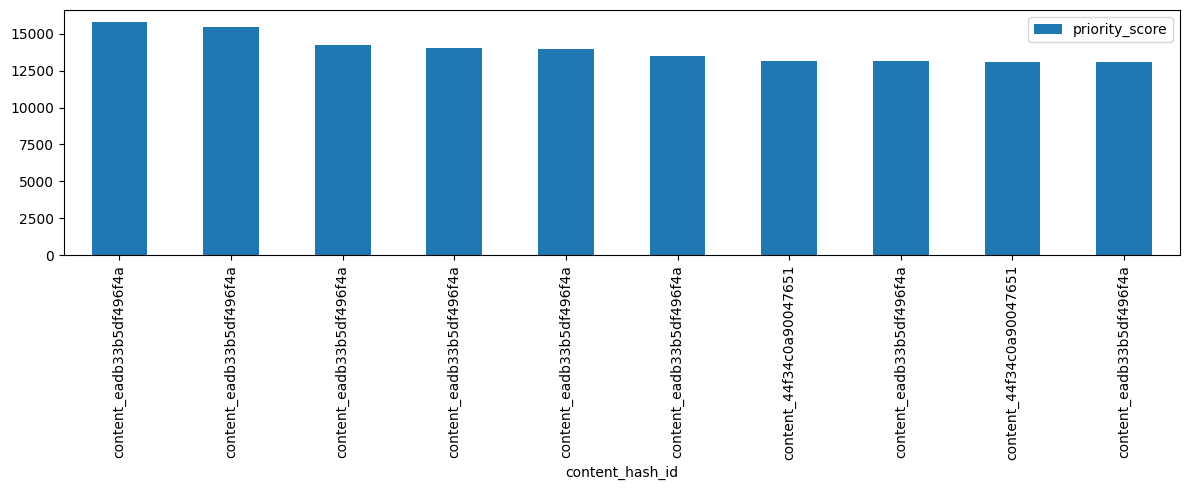

In [10]:
import matplotlib.pyplot as plt

baseline.head(10).plot(
    x="content_hash_id",
    y="priority_score",
    kind="bar",
    figsize=(12,5)
)

plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

plt.savefig(
    "work/figures/top10_priority.png"
)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.